In [ ]:
!rm -rf diploma_centpy_parallelization_py
# Флаг -b указывает конкретную ветку
!git clone -b feature/jax-centpy https://github.com/filkinc/diploma_centpy_parallelization_py.git
%cd diploma_centpy_parallelization_py
%cd /content/diploma_centpy_parallelization_py/jax_centpy

!pip install centpy pandas matplotlib seaborn

Cloning into 'diploma_centpy_parallelization_py'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 107 (delta 32), reused 91 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 19.81 MiB | 22.61 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/diploma_centpy_parallelization_py
/content/diploma_centpy_parallelization_py/jax_centpy


In [ ]:
import os

# ЭМУЛЯЦИЯ 8 ЯДЕР CPU
# Это нужно сделать ДО импорта JAX!
#os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=8"

import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sys

print(f"JAX Version: {jax.__version__}")
print(f"Devices Available: {jax.devices()}")
print(f"Platform: {jax.devices()[0].platform.upper()}")

JAX Version: 0.7.2
Devices Available: [CpuDevice(id=0)]
Platform: CPU


In [ ]:
try:
    from core import Pars1d, Equation1d
    from equations import make_burgers_1d
    from solver import Solver1d
    from parallel_solver import ParallelSolver1d
    from benchmark_1d import run_solver_benchmark
    print("Library imported successfully!")
except ImportError as e:
    print(f"Error importing library: {e}")
    print("Make sure you uploaded core.py, solver.py, etc. to the Colab files section!")

Library imported successfully!


In [ ]:
# --- centpy ---
def run_centpy_benchmark(grid_sizes):
    import centpy
    results = []
    print("Running CentPy (CPU)...")

    class Burgers1dCP(centpy.Equation1d):
        def initial_data(self): return np.sin(self.x) + 0.5*np.sin(0.5*self.x)
        def boundary_conditions(self, u): u[0]=u[-4]; u[1]=u[-3]; u[-2]=u[2]; u[-1]=u[3]
        def flux_x(self, u): return 0.5*u**2
        def spectral_radius_x(self, u): return np.abs(u)

    for J in grid_sizes:
        try:
            pars = centpy.Pars1d(x_init=0.0, x_final=6.28, t_final=1.0, dt_out=1.0, J=J, cfl=0.45, scheme="sd2")
            eqn = Burgers1dCP(pars)
            solver = centpy.Solver1d(eqn)

            start = time.time()
            solver.solve()
            duration = time.time() - start

            print(f"  Grid {J}: {duration:.4f} s")
            results.append({"Grid": J, "Time": duration, "Method": "CentPy (Original)"})
        except Exception as e:
            print(f"  Grid {J} Failed: {e}")

    return pd.DataFrame(results)

In [ ]:
import time
import pandas as pd
import jax
import numpy as np
import centpy

def run_solver_benchmark_colab(solver_class, eqn, scheme, label, grids):
    results = []
    print(f"\n--- Benchmarking: {label} ---")

    for J in grids:
        try:
            pars = Pars1d(
                x_init=0.0, x_final=6.28, t_final=1.0, dt_out=1.0,
                J=J, cfl=0.45, scheme=scheme
            )

            solver = solver_class(pars, eqn, scheme_name=scheme)

            print(f"  Grid {J}: Warming up...", end="\r")
            warmup_start = time.time()
            res_warm = solver.solve()

            if hasattr(res_warm.get('u_n'), 'block_until_ready'):
                res_warm['u_n'].block_until_ready()

            warmup_time = time.time() - warmup_start

            print(f"  Grid {J}: Running...      ", end="\r")
            start = time.time()
            res = solver.solve()

            if hasattr(res.get('u_n'), 'block_until_ready'):
                res['u_n'].block_until_ready()

            duration = time.time() - start

            steps = res.get('steps', -1)
            if steps == -1:
                steps = int(pars.t_final / (pars.cfl * pars.dx)) # Грубая оценка

            print(f"  Grid {J}: {duration:.4f} s (Warmup: {warmup_time:.2f} s) Steps: {steps}")

            results.append({
                "Grid": J,
                "Time": duration,
                "Method": label,
                "Steps": steps,
                "Cells_Sec": (J * steps) / duration if steps > 0 else 0
            })

        except Exception as e:
            print(f"  Grid {J}: Failed ({e})")

    return pd.DataFrame(results)


In [ ]:
from typing import Tuple
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

class FastSolver1d(Solver1d):
    """
    Оптимизированная версия солвера для бенчмарков.
    Использует jax.lax.while_loop для выполнения всего цикла на устройстве.
    Не сохраняет промежуточные шаги (только начальное и конечное состояние).
    """
    def __init__(self, pars, eqn, scheme_name="sd2"):
        super().__init__(pars, eqn, scheme_name)

        self.solve_jit = jax.jit(self._solve_internal)

    def _solve_internal(self, u0):

        def cond_fun(state):
            t, _, _ = state
            return t < self.pars.t_final

        def body_fun(state):
            t, u, step_idx = state

            max_speed = jnp.max(self.eqn.spectral_radius(u))
            safe_speed = jnp.maximum(max_speed, 1e-6)
            dt = self.pars.cfl * self.pars.dx / safe_speed

            dt = jnp.minimum(dt, self.pars.t_final - t)

            u_new = self.step_fn(t, u, dt, self.rhs_fn)

            return t + dt, u_new, step_idx + 1

        init_state = (0.0, u0, 0)
        final_t, final_u, final_steps = jax.lax.while_loop(cond_fun, body_fun, init_state)

        return final_t, final_u, final_steps

    def solve(self):
        dx = self.pars.dx
        x = jnp.linspace(self.pars.x_init + dx/2, self.pars.x_final - dx/2, self.pars.J)
        u0 = self.eqn.initial_data(x)
        
        final_t, final_u, steps = self.solve_jit(u0)


        return {
            "x": x,
            "t": jnp.array([0.0, final_t]),
            "u_n": jnp.stack([u0, final_u]),
            "steps": steps
        }


In [ ]:
class ScanSolver1d(Solver1d):
    def __init__(self, pars, eqn, scheme_name="sd2"):
        super().__init__(pars, eqn, scheme_name)
        
        self.fixed_dt = pars.cfl * pars.dx / 1.0 # Предполлагаем скорость волны ~1.0
        
        self.num_steps = int(pars.t_final / self.fixed_dt) + 1

        
        def scan_body(u, _):
            u_new = self.step_fn(0.0, u, self.fixed_dt, self.rhs_fn)
            return u_new, None

        self.scan_fn = jax.jit(lambda u0: jax.lax.scan(scan_body, u0, None, length=self.num_steps))

    def solve(self):
        dx = self.pars.dx
        x = jnp.linspace(self.pars.x_init + dx/2, self.pars.x_final - dx/2, self.pars.J)
        u0 = self.eqn.initial_data(x)

        final_u, _ = self.scan_fn(u0)
        final_u.block_until_ready()

        return {
            "x": x,
            "t": jnp.array([0.0, self.pars.t_final]),
            "u_n": jnp.stack([u0, final_u])
        }


In [ ]:
import jax
import jax.numpy as jnp
from functools import partial

# Импортируем твои функции (они должны быть чистыми)
from schemes import compute_rhs_sd2
from time_integration import step_ssp_rk3

# Чистая функция для scan
@partial(jax.jit, static_argnums=(2, 3))
def scan_step_rk3(u, _, pars, eqn):
    dt = pars.cfl * pars.dx / 1.0

    def rhs(t, u_loc):
        return compute_rhs_sd2(t, u_loc, pars, eqn)

    u_new = step_ssp_rk3(0.0, u, dt, rhs)
    return u_new, None

class FunctionalSolver:
    def __init__(self, pars, eqn, scheme_name="sd2"):
        self.pars = pars
        self.eqn = eqn
        
        self.fixed_dt = pars.cfl * pars.dx / 1.0
        self.num_steps = int(pars.t_final / self.fixed_dt) + 1

        self.scan_jit = jax.jit(
            lambda u0: jax.lax.scan(
                lambda c, x: scan_step_rk3(c, x, self.pars, self.eqn),
                u0,
                None,
                length=self.num_steps
            )
        )

    def solve(self):
        dx = self.pars.dx
        x = jnp.linspace(self.pars.x_init + dx/2, self.pars.x_final - dx/2, self.pars.J)
        u0 = self.eqn.initial_data(x)

        final_u, _ = self.scan_jit(u0)

        if hasattr(final_u, 'block_until_ready'):
            final_u.block_until_ready()

        return {
            "x": x,
            "t": jnp.array([0.0, self.pars.t_final]), # Фейк
            "u_n": jnp.stack([u0, final_u])
        }


=== CPU BENCHMARK START ===

🐢 Running CentPy (Original)...
  Grid 1000: 0.0956 s (Steps: -1)
  Grid 5000: 0.9335 s (Steps: -1)
  Grid 10000: 3.5881 s (Steps: -1)

--- Benchmarking: JAX (CPU 1 Core) ---
  Grid 1000: 0.1920 s (Warmup: 0.95 s) Steps: 484
  Grid 5000: 3.5690 s (Warmup: 4.57 s) Steps: 2421
  Grid 10000: 12.3372 s (Warmup: 12.50 s) Steps: 4841

 Benchmark Finished! Saved to cpu_sd2_1d_burgers_1000_10000.csv
    Grid       Time             Method  Steps     Cells_Sec
0   1000   0.095605  CentPy (Original)     -1  0.000000e+00
1   5000   0.933466  CentPy (Original)     -1  0.000000e+00
2  10000   3.588145  CentPy (Original)     -1  0.000000e+00
0   1000   0.191981   JAX (CPU 1 Core)    484  2.521079e+06
1   5000   3.569000   JAX (CPU 1 Core)   2421  3.391707e+06
2  10000  12.337177   JAX (CPU 1 Core)   4841  3.923912e+06


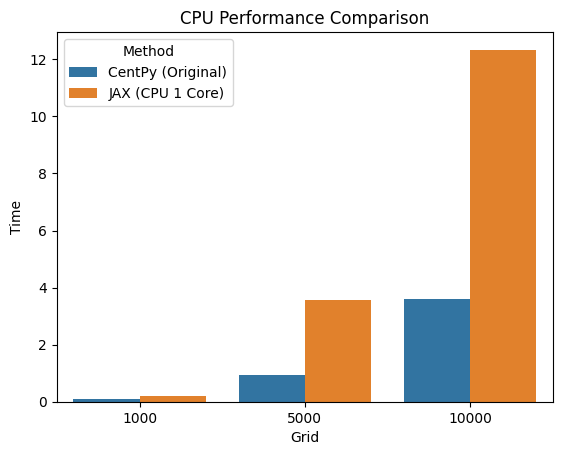

In [ ]:
# --- CPU benchmarks ---
print("=== CPU BENCHMARK START ===")

#GRIDS = [1000, 2000, 4000, 8000]
GRIDS = [1000, 5000, 10000]

df_centpy = run_centpy_benchmark(GRIDS)

eqn = make_burgers_1d()

df_jax_single = run_solver_benchmark_colab(FastSolver1d, eqn, "sd2", "JAX (CPU 1 Core)", GRIDS)
#df_jax_parallel = run_solver_benchmark(ParallelSolver1d, eqn, "sd2", "JAX (CPU 8 Cores Sim)", GRIDS)

#df_final = pd.concat([df_centpy, df_jax_single, df_jax_parallel])
df_final = pd.concat([df_centpy, df_jax_single])
filename = f"cpu_sd2_1d_burgers_{min(GRIDS)}_{max(GRIDS)}.csv"
df_final.to_csv(filename, index=False)

print(f"\n Benchmark Finished! Saved to {filename}")
print(df_final)

sns.barplot(data=df_final, x="Grid", y="Time", hue="Method")
plt.title("CPU Performance Comparison")
plt.show()


In [ ]:
# --- DEBUG: Raw Kernel Benchmark ---

import jax
import jax.numpy as jnp
import time

jax.config.update("jax_enable_x64", True)

J = 10000
x = jnp.linspace(0.0, 2*jnp.pi, J)
u0 = jnp.sin(x) + 0.5*jnp.sin(0.5*x)

from equations import make_burgers_1d
from core import Pars1d
from schemes import compute_rhs_sd2

pars = Pars1d(0.0, 2*jnp.pi, 1.0, 1.0, J, 0.45, "sd2")
eqn = make_burgers_1d()

def rhs_wrapper(u):
    return compute_rhs_sd2(0.0, u, pars, eqn)

rhs_jit = jax.jit(rhs_wrapper)

# Warmup
_ = rhs_jit(u0).block_until_ready()

# Benchmark
start = time.time()
for _ in range(1000):
    u0 = u0 + 0.0001 * rhs_jit(u0)
u0.block_until_ready()
print("Time:", time.time() - start)

In [ ]:
# --- DEBUG: Raw Kernel Benchmark ---
import time
import jax
import jax.numpy as jnp
from schemes import compute_rhs_sd2
from core import Pars1d
from equations import make_burgers_1d

def raw_kernel_benchmark():
    print("--- RAW KERNEL DEBUG ---")
    J = 10000
    # Создаем данные
    u = jnp.zeros(J)
    pars = Pars1d(0.0, 6.28, 1.0, 1.0, J, 0.45, "sd2")
    eqn = make_burgers_1d()

    # Компилируем чистую функцию шага (Эйлер для простоты, или RK3 вручную)
    # Чтобы исключить влияние классов
    def step_fn(u):
        # Хардкодим dt и схему
        dt = 0.0001
        rhs = compute_rhs_sd2(0.0, u, pars, eqn)
        return u + dt * rhs

    # Scan на 1000 шагов
    scan_fn = jax.jit(lambda u: jax.lax.scan(lambda c, x: (step_fn(c), None), u, None, length=1000))

    # Warmup
    print("Warming up...")
    res, _ = scan_fn(u)
    res.block_until_ready()

    # Run
    print("Running 1000 steps...")
    start = time.time()
    res, _ = scan_fn(u)
    res.block_until_ready()
    end = time.time()

    print(f"Time for 1000 steps: {end - start:.4f} s")

raw_kernel_benchmark()
